   Transaction_Amount
0           52.483571
1           49.308678
2           53.238443
3           57.615149
4           48.829233

Detected Anomalies:

     Transaction_Amount  Anomaly
74            36.901274        1
113           62.316211        1
125           60.952278        1
179           63.600846        1
200           80.715575        1
201           81.121569        1
202           82.166102        1
203           82.107604        1
204           77.244661        1
205           78.124350        1
209           87.705463        1


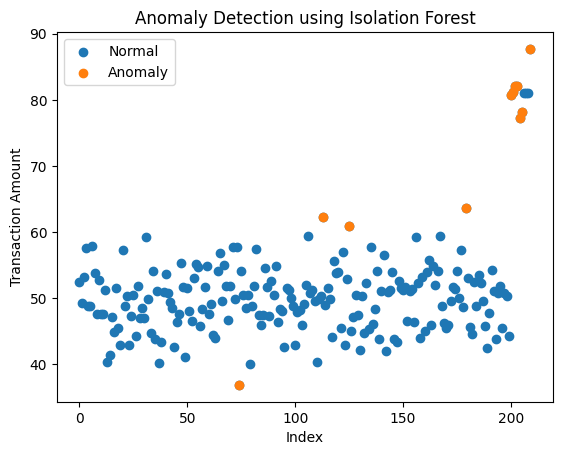

In [1]:
# ================================
# IMPORT LIBRARIES
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

# ================================
# CREATE SAMPLE DATA
# ================================
np.random.seed(42)

# Normal data
normal_data = np.random.normal(loc=50, scale=5, size=200)

# Anomalies (fraud-like)
anomalies = np.random.normal(loc=80, scale=2, size=10)

data = np.concatenate([normal_data, anomalies])

df = pd.DataFrame(data, columns=['Transaction_Amount'])

print(df.head())

# ================================
# MODEL (ISOLATION FOREST)
# ================================
model = IsolationForest(contamination=0.05)

df['Anomaly'] = model.fit_predict(df)

# Convert output:
# -1 → anomaly
#  1 → normal
df['Anomaly'] = df['Anomaly'].map({1: 0, -1: 1})

print("\nDetected Anomalies:\n")
print(df[df['Anomaly'] == 1])

# ================================
# VISUALIZATION
# ================================
plt.figure()

plt.scatter(df.index, df['Transaction_Amount'], label='Normal')
plt.scatter(df[df['Anomaly']==1].index,
            df[df['Anomaly']==1]['Transaction_Amount'],
            label='Anomaly')

plt.xlabel("Index")
plt.ylabel("Transaction Amount")
plt.title("Anomaly Detection using Isolation Forest")
plt.legend()

plt.show()